Telco Customer Churn - Modelos ANN Telco Customer Churn - Modelos ANN

Sistema de predicción de abandono de clientes (Churn) usando Redes Neuronales Artificiales. Se implementan dos modelos: uno de clasificación binaria (Churn Yes/No) y otro de regresión (probabilidad de riesgo entre 0.0 y 1.0).

Dataset: Telco Customer Churn (Kaggle)


Importar librerías

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam as KerasAdam
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

Cargar dataset

In [2]:
df = pd.read_csv(r"C:\Users\Jesus\Downloads\ANN Regresión-20260529\customer_clean.csv")

In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_DSL,InternetService_Fiber optic,InternetService_No
0,0,0,1,0,1,0,0,0,1,0,...,1,0,0,0,0,1,0,1,0,0
1,1,0,0,0,34,1,0,1,0,1,...,0,1,0,0,0,0,1,1,0,0
2,1,0,0,0,2,1,0,1,1,0,...,1,0,0,0,0,0,1,1,0,0
3,1,0,0,0,45,0,0,1,0,1,...,0,1,0,1,0,0,0,1,0,0
4,0,0,0,0,2,1,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0


Preprocesamiento

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

eparar variables predictoras y variable objetivo

In [5]:
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Shape X:", X.shape)
print("Distribución Churn:", y.value_counts())


Shape X: (7032, 26)
Distribución Churn: Churn
0    5163
1    1869
Name: count, dtype: int64


Visualizacion Variable objetivo

<Axes: xlabel='Churn', ylabel='count'>

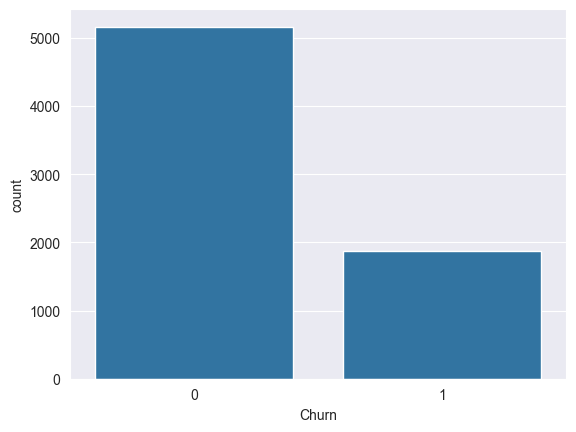

In [6]:
sns.countplot(x='Churn',data=df)

In [8]:
df.dropna(inplace=True)
df.isnull().sum()

gender                                     0
SeniorCitizen                              0
Partner                                    0
Dependents                                 0
tenure                                     0
PhoneService                               0
MultipleLines                              0
OnlineSecurity                             0
OnlineBackup                               0
DeviceProtection                           0
TechSupport                                0
StreamingTV                                0
StreamingMovies                            0
PaperlessBilling                           0
MonthlyCharges                             0
TotalCharges                               0
Churn                                      0
Contract_Month-to-month                    0
Contract_One year                          0
Contract_Two year                          0
PaymentMethod_Bank transfer (automatic)    0
PaymentMethod_Credit card (automatic)      0
PaymentMet

 Codificación de variables categóricas

Todas las variables categóricas se transforman a numéricas usando `LabelEncoder`, conservando las 19 variables predictoras del dataset (se excluye `customerID` por no aportar valor predictivo).Codificación de variables categóricas

In [10]:
X = df.drop('Churn', axis=1)

Balanceo con SMOTE

Aplicamos SMOTE para generar muestras sintéticas de la clase minoritaria (Churn=1) y balancear el dataset antes del entrenamiento. Balanceo con SMOTE

In [11]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

print("Distribución después de SMOTE:", np.bincount(y_res.astype(int)))

Distribución después de SMOTE: [5163 5163]


 Normalización

Escalamos las variables con `StandardScaler` para mejorar la convergencia de las redes neuronales.Normalización

In [12]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

In [13]:
X.shape

(7032, 26)

 Train/Test Split

Dividimos el conjunto de datos balanceado y escalado en entrenamiento (80%) y prueba (20%), verificando que ambas clases queden representadas correctamente.TrainTest split

In [15]:
X = df.drop('Churn',axis=1).values
y = df['Churn'].values

In [16]:

X_train, X_test, y_train, y_test = train_test_split(
    X_res_scaled, y_res,
    test_size=0.2,
    random_state=42
)

print("Distribución y_train:", np.bincount(y_train.astype(int)))
print("Distribución y_test:", np.bincount(y_test.astype(int)))

Distribución y_train: [4126 4134]
Distribución y_test: [1037 1029]


Creacion de los modelos

Early_stopping

In [17]:


early_stop_class = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True)
reduce_lr_class  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=7, min_lr=1e-6)

early_stop_reg = EarlyStopping(monitor='val_mae', patience=20, restore_best_weights=True)
reduce_lr_reg  = ReduceLROnPlateau(monitor='val_mae', factor=0.5, patience=7, min_lr=1e-6)



 Modelo 1 - Clasificación Binaria (Churn Yes/No)

Red neuronal con capas densas, `BatchNormalization` y `Dropout` para evitar sobreajuste. La capa de salida usa activación `sigmoid` para obtener una probabilidad entre 0 y 1.1-Modelo_Clasificacion

In [18]:
model_class = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_class.compile(
    optimizer=KerasAdam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_class = model_class.fit(
    X_train, y_train,
    epochs=400,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_class, reduce_lr_class],
    verbose=1
)

Epoch 1/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7466 - loss: 0.5102 - val_accuracy: 0.8136 - val_loss: 0.4153 - learning_rate: 3.0000e-04
Epoch 2/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8051 - loss: 0.4149 - val_accuracy: 0.8228 - val_loss: 0.3882 - learning_rate: 3.0000e-04
Epoch 3/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8229 - loss: 0.3899 - val_accuracy: 0.8204 - val_loss: 0.3823 - learning_rate: 3.0000e-04
Epoch 4/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8245 - loss: 0.3776 - val_accuracy: 0.8243 - val_loss: 0.3743 - learning_rate: 3.0000e-04
Epoch 5/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8257 - loss: 0.3703 - val_accuracy: 0.8248 - val_loss: 0.3683 - learning_rate: 3.0000e-04
Epoch 6/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8275 - loss: 0.3643 - val_accuracy: 0.8335 - val_loss: 0.3669 - learning_rate: 3.0000e-04
Epoch 7/400
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc

 Modelo 2 - Regresión (Probabilidad de Churn 0.0 - 1.0)

Red neuronal más profunda (512 → 256 → 128 → 64 → 32) entrenada con función de pérdida `huber`, más robusta ante valores atípicos que el MSE tradicional. La salida usa `sigmoid` ya que predice una probabilidad acotada entre 0 y 1.2-Modelo regresion

In [19]:
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),  # 26 features
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_reg.compile(
    optimizer=KerasAdam(learning_rate=0.0005),
    loss='huber',
    metrics=['mae']
)

history_reg = model_reg.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop_reg, reduce_lr_reg],
    verbose=1
)


Epoch 1/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0757 - mae: 0.2777 - val_loss: 0.0692 - val_mae: 0.2753 - learning_rate: 5.0000e-04
Epoch 2/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0626 - mae: 0.2406 - val_loss: 0.0600 - val_mae: 0.2294 - learning_rate: 5.0000e-04
Epoch 3/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0593 - mae: 0.2292 - val_loss: 0.0602 - val_mae: 0.2191 - learning_rate: 5.0000e-04
Epoch 4/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0583 - mae: 0.2266 - val_loss: 0.0594 - val_mae: 0.2148 - learning_rate: 5.0000e-04
Epoch 5/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0574 - mae: 0.2202 - val_loss: 0.0581 - val_mae: 0.2191 - learning_rate: 5.0000e-04
Epoch 6/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0570 - mae: 0.2229 - val_loss: 0.0582 - val_mae: 0.2135 - learning_rate: 5.0000e-04
Epoch 7/300
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0562 - mae: 0.2188 - val_loss: 0.0580 - val_mae: 0.2148

Evaluacion

In [20]:
loss_class, acc_class = model_class.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Clasificación - Accuracy: {acc_class:.2f}")

loss_reg, mae_reg = model_reg.evaluate(X_test, y_test, verbose=0)
print(f"Modelo Regresión - MAE: {mae_reg:.2f}")

Modelo Clasificación - Accuracy: 0.84
Modelo Regresión - MAE: 0.20


Visualizaciones

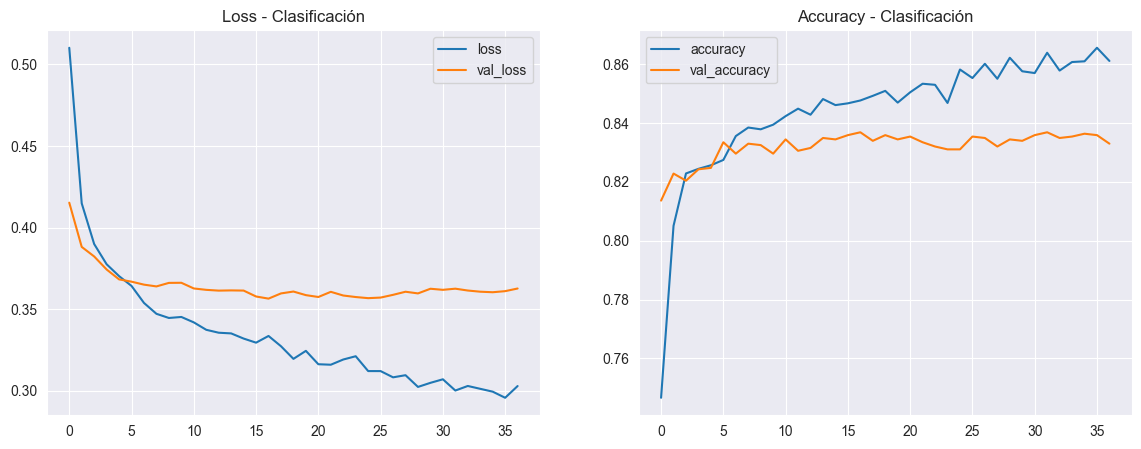

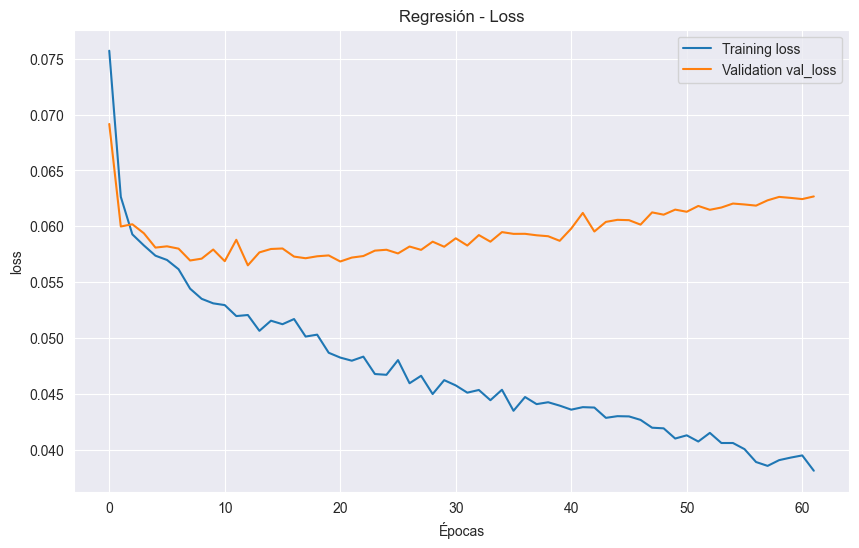

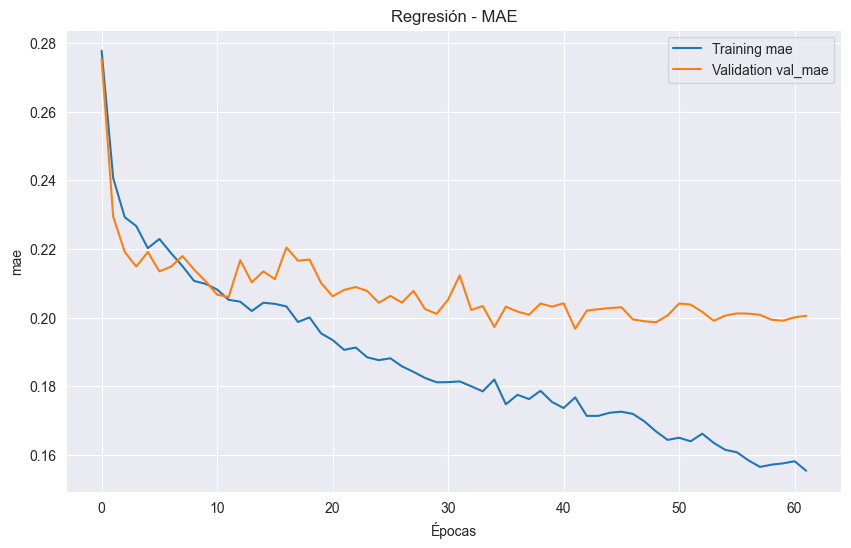

In [21]:
model_loss = pd.DataFrame(history_class.history)
fig, axes = plt.subplots(1, 2, figsize=(14,5))
model_loss[['loss','val_loss']].plot(ax=axes[0], title='Loss - Clasificación')
model_loss[['accuracy','val_accuracy']].plot(ax=axes[1], title='Accuracy - Clasificación')
plt.show()

def plot_history(history, metric, val_metric, title):
    plt.figure(figsize=(10,6))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[val_metric], label=f'Validation {val_metric}')
    plt.title(title)
    plt.xlabel("Épocas")
    plt.ylabel(metric)
    plt.legend()
    plt.show()

plot_history(history_reg, 'loss', 'val_loss', "Regresión - Loss")
plot_history(history_reg, 'mae', 'val_mae', "Regresión - MAE")

 Gráfica de Loss y Accuracy - Modelo de Clasificación

Las curvas de entrenamiento y validación convergen sin separación significativa, lo que indica que el modelo no presenta overfitting grave. El accuracy se estabiliza alrededor de 0.83. Gráfica de Loss y Accuracy para clasificación

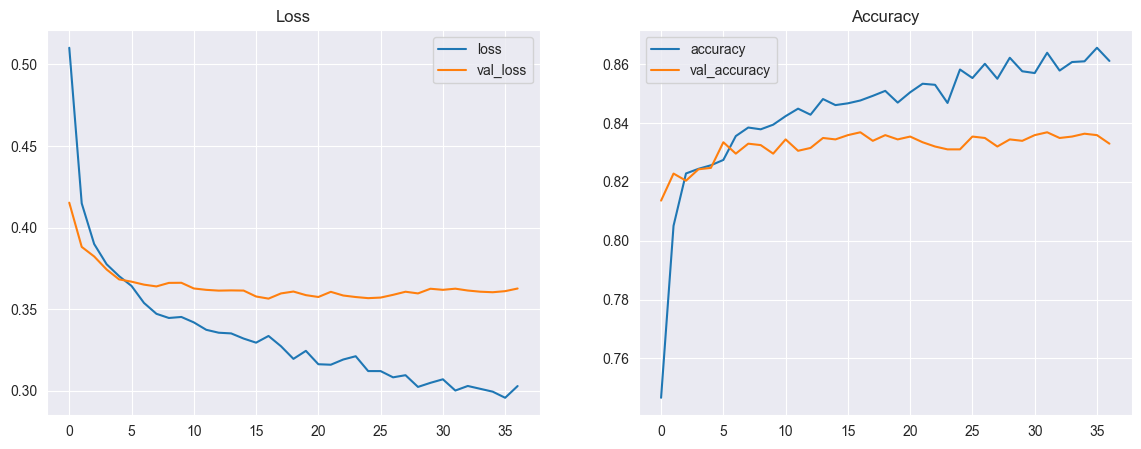

In [22]:
model_loss = pd.DataFrame(history_class.history)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

model_loss[['loss','val_loss']].plot(ax=axes[0], title='Loss')
model_loss[['accuracy','val_accuracy']].plot(ax=axes[1], title='Accuracy')

plt.show()

Gráfica de Loss y MAE para regresión

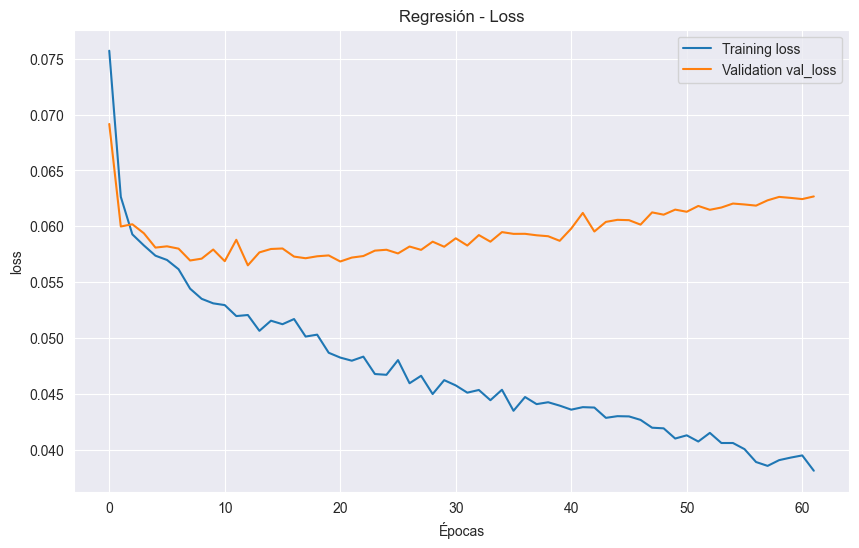

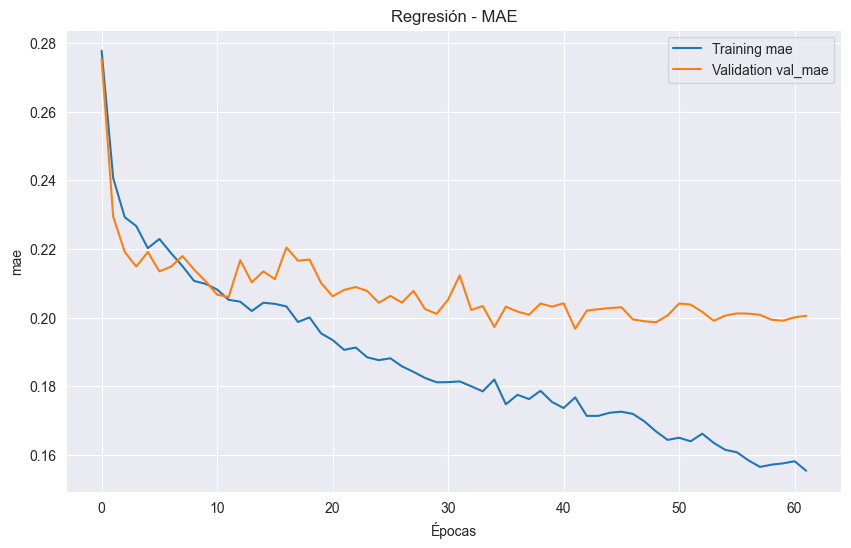

In [23]:
plot_history(history_reg, 'loss', 'val_loss', "Regresión - Loss")
plot_history(history_reg, 'mae', 'val_mae', "Regresión - MAE")

Predicciones
 Predicciones del modelo de regresión

Generamos las predicciones de probabilidad de churn sobre el conjunto de prueba, que servirán como base para la segmentación de clientes por nivel de riesgo.

Definir Riesgos
 Definición de niveles de riesgo

Clasificamos las probabilidades predichas en tres niveles de riesgo:
- **Bajo:** probabilidad < 0.33
- **Medio:** 0.33 ≤ probabilidad < 0.66
- **Alto:** probabilidad ≥ 0.66

In [24]:
y_pred_reg = model_reg.predict(X_test).flatten()

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [25]:
def segmentar_riesgo(prob):
    if prob < 0.33:
        return "Bajo"
    elif prob < 0.66:
        return "Medio"
    else:
        return "Alto"

segmentos = np.array([segmentar_riesgo(p) for p in y_pred_reg])

Distribución de clientes por nivel de riesgo

In [26]:
unique, counts = np.unique(segmentos, return_counts=True)
segment_counts = dict(zip(unique, counts))
print("Distribución de clientes por riesgo:", segment_counts)

Distribución de clientes por riesgo: {np.str_('Alto'): np.int64(908), np.str_('Bajo'): np.int64(932), np.str_('Medio'): np.int64(226)}


 Visualización de la segmentación por nivel de riesgo

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Distribución de clientes por riesgo: {np.str_('Alto'): np.int64(908), np.str_('Bajo'): np.int64(932), np.str_('Medio'): np.int64(226)}


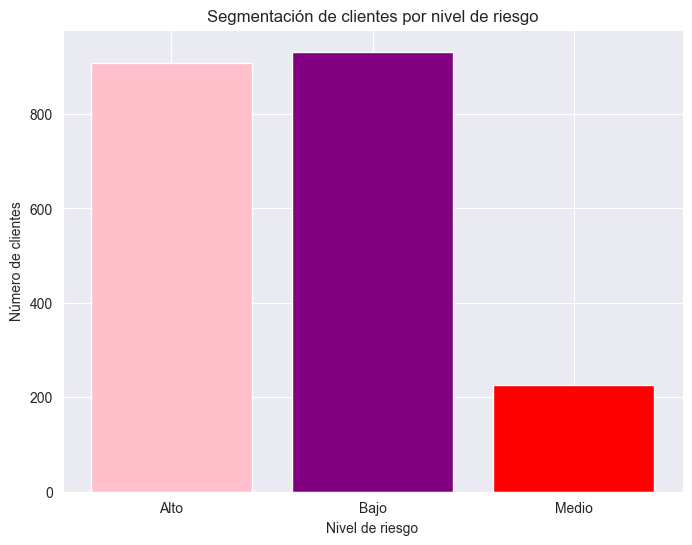

In [27]:
y_pred_reg = model_reg.predict(X_test).flatten()

def segmentar_riesgo(prob):
    if prob < 0.33:
        return "Bajo"
    elif prob < 0.66:
        return "Medio"
    else:
        return "Alto"

segmentos = np.array([segmentar_riesgo(p) for p in y_pred_reg])

unique, counts = np.unique(segmentos, return_counts=True)
segment_counts = dict(zip(unique, counts))
print("Distribución de clientes por riesgo:", segment_counts)

plt.figure(figsize=(8,6))
plt.bar(segment_counts.keys(), segment_counts.values(), color=['pink','purple','red'])
plt.title("Segmentación de clientes por nivel de riesgo")
plt.xlabel("Nivel de riesgo")
plt.ylabel("Número de clientes")
plt.show()

Exportar modelos para API

In [28]:
model_class.save("model_churn_class.keras")
model_reg.save("model_churn_reg.keras")


In [29]:
import pickle
pickle.dump(scaler, open(r"C:\Users\Jesus\Downloads\ANN Regresión-20260529\scaler.pkl", "wb"))
print("Scaler guardado")

Scaler guardado
